# Four-market Heston sampling calibration

Review the workstation sweep, explicitly choose one interval for each market, then inspect the final independent-ensemble results. This notebook reads CSVs and PNGs; optimization and simulations run on the workstation.


In [11]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

ROOT = Path.cwd().resolve()
if not (ROOT / 'data').is_dir():
    ROOT = ROOT.parent
DATA = ROOT / 'data/processed/heston_calibration/four_market_sampling_sweep'
FIGURES = ROOT / 'visualization/heston_calibration/four_market_sampling_sweep'
MARKETS = ('UN', 'UW', 'LN', 'JT')
summary = {}
for market in MARKETS:
    path = DATA / market / f'{market}_sampling_fit_sweep.csv'
    if path.is_file():
        frame = pd.read_csv(path).sort_values('interval_steps').reset_index(drop=True)
        frame['interval_steps'] = frame.interval_steps.astype(int)
        frame['validation_loss'] = pd.to_numeric(frame.validation_loss, errors='coerce')
        summary[market] = frame
    else:
        print(f'Missing sweep summary: {path}')
print('Available markets:', ', '.join(summary) or 'none')


Available markets: UN, UW, LN, JT


## Compare fit scores and return scale

`validation_loss` is measured on an independent full-length synthetic ensemble. Compare it with MFHT coverage and the return PDF before choosing an interval.


UN


,interval_steps,pilot_loss,validation_loss,optimization_success,empirical_average_std,synthetic_average_std,empirical_mass_abs_le_0p0025,synthetic_mass_abs_le_0p0025,a,b,aa,bb,cc,vstart
0,1,0.16756,0.17125,True,0.0236,0.02369,0.17848,0.16441,0.61628,2.42722,2.05486,0.02021,0.78426,0.02702
1,2,0.17318,0.17853,False,0.0236,0.02371,0.17848,0.16638,0.46432,1.01429,1.47445,0.00806,0.51228,0.01278
2,5,0.17922,0.18356,False,0.0236,0.02450,0.17848,0.15076,0.31261,0.50682,0.82504,0.00974,0.19905,0.01776
3,10,0.20623,0.20861,False,0.0236,0.02467,0.17848,0.10825,0.35248,0.97118,5.61154,0.00051,0.42260,0.01978


UW


,interval_steps,pilot_loss,validation_loss,optimization_success,empirical_average_std,synthetic_average_std,empirical_mass_abs_le_0p0025,synthetic_mass_abs_le_0p0025,a,b,aa,bb,cc,vstart
0,1,0.57253,0.57832,True,0.04174,0.04144,0.138,0.08028,0.85341,2.63904,5.44395,0.08430,1.82106,0.02086
1,2,0.57466,0.57843,True,0.04174,0.04306,0.138,0.07822,0.42027,1.95734,4.24011,0.01608,1.40268,0.01240
2,5,0.57402,0.58199,True,0.04174,0.04492,0.138,0.07327,0.21888,0.73988,2.28478,0.02011,0.66653,0.04010
3,10,0.58059,0.58498,False,0.04174,0.04256,0.138,0.07123,0.37678,0.59244,3.01208,0.00159,0.56893,0.00664


LN


,interval_steps,pilot_loss,validation_loss,optimization_success,empirical_average_std,synthetic_average_std,empirical_mass_abs_le_0p0025,synthetic_mass_abs_le_0p0025,a,b,aa,bb,cc,vstart
0,1,0.29815,0.32990,False,0.02876,0.02899,0.42559,0.23382,1.05684,4.73536,0.07811,0.00392,0.34621,0.03828
1,2,0.31358,0.33639,False,0.02876,0.02771,0.42559,0.25614,2.92765,4.32541,0.07256,0.00495,0.20505,0.03146
2,5,0.33990,0.34110,False,0.02876,0.02887,0.42559,0.23874,2.44965,6.00858,0.07226,0.00370,0.13649,0.04847
3,10,0.34136,0.34360,False,0.02876,0.03278,0.42559,0.12305,1.24490,2.63195,0.59509,0.00160,0.25882,0.03372


JT


,interval_steps,pilot_loss,validation_loss,optimization_success,empirical_average_std,synthetic_average_std,empirical_mass_abs_le_0p0025,synthetic_mass_abs_le_0p0025,a,b,aa,bb,cc,vstart
0,1,0.19011,0.19437,True,0.03788,0.03889,0.18594,0.09638,0.41184,1.13160,5.74262,0.00510,2.02992,0.02780
1,2,0.18397,0.18491,False,0.03788,0.03923,0.18594,0.08800,0.21384,0.76736,4.97554,0.00196,1.40718,0.02885
2,5,0.18140,0.18213,False,0.03788,0.03831,0.18594,0.08727,0.24297,0.59334,2.84748,0.00142,0.71355,0.01395
3,10,0.18771,0.18862,False,0.03788,0.03810,0.18594,0.08803,0.21733,0.78826,1.54450,0.00041,0.41320,0.02136


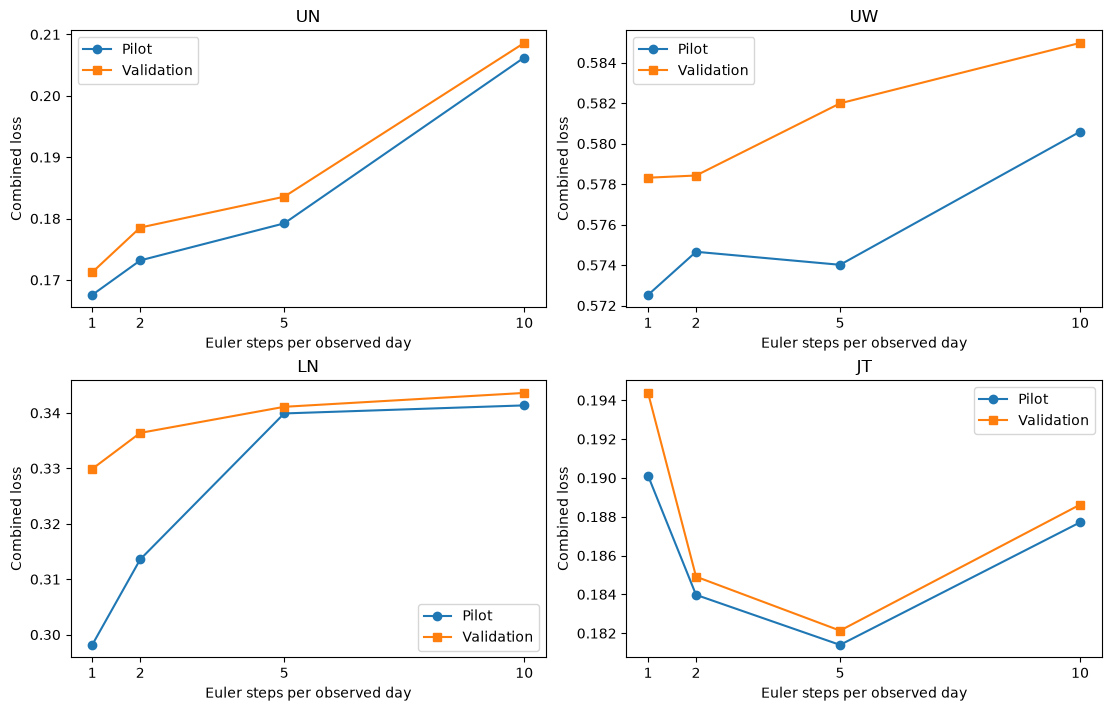

In [12]:
for market, frame in summary.items():
    print(market)
    display(frame[['interval_steps', 'pilot_loss', 'validation_loss', 'optimization_success',
                   'empirical_average_std', 'synthetic_average_std',
                   'empirical_mass_abs_le_0p0025', 'synthetic_mass_abs_le_0p0025',
                   'a', 'b', 'aa', 'bb', 'cc', 'vstart']].round(5))
if summary:
    fig, axes = plt.subplots(2, 2, figsize=(11, 7), layout='constrained')
    for ax, market in zip(axes.flat, MARKETS):
        if market not in summary:
            ax.set_visible(False)
            continue
        frame = summary[market]
        ax.plot(frame.interval_steps, frame.pilot_loss, 'o-', label='Pilot')
        ax.plot(frame.interval_steps, frame.validation_loss, 's-', label='Validation')
        ax.set(title=market, xlabel='Euler steps per observed day', ylabel='Combined loss',
               xticks=frame.interval_steps)
        ax.legend()
    plt.show()


## Inspect MFHT curves and return PDFs

Each row is one market; columns are the fitted sampling intervals. MFHT titles show covered empirical fit bins.


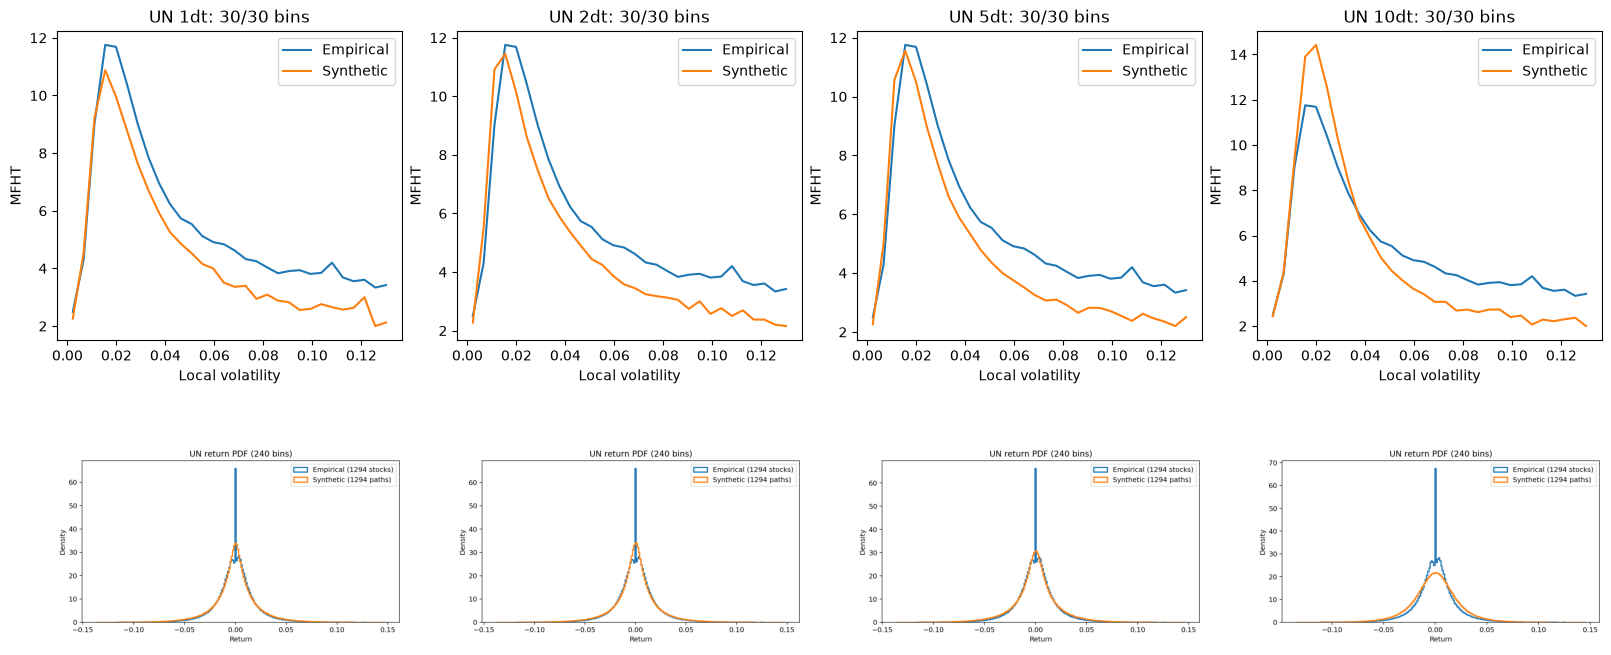

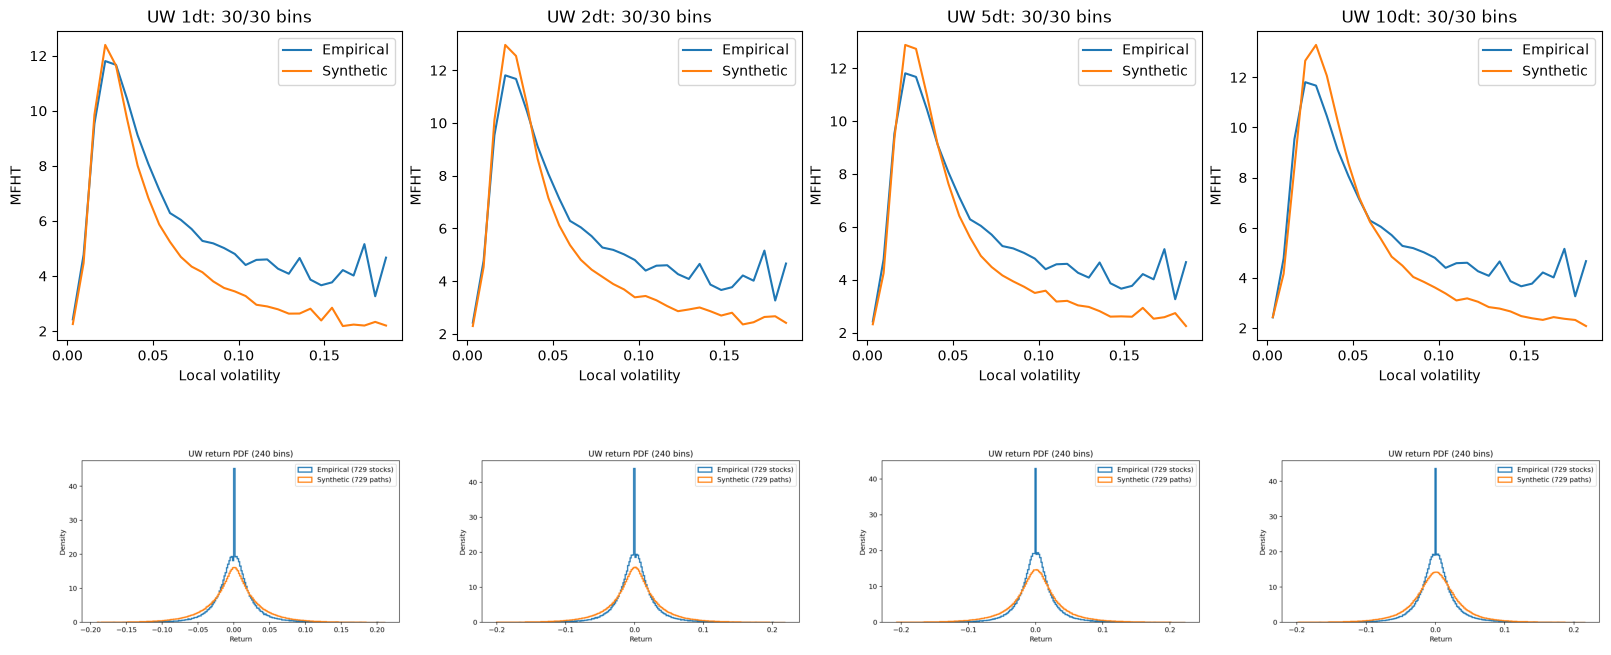

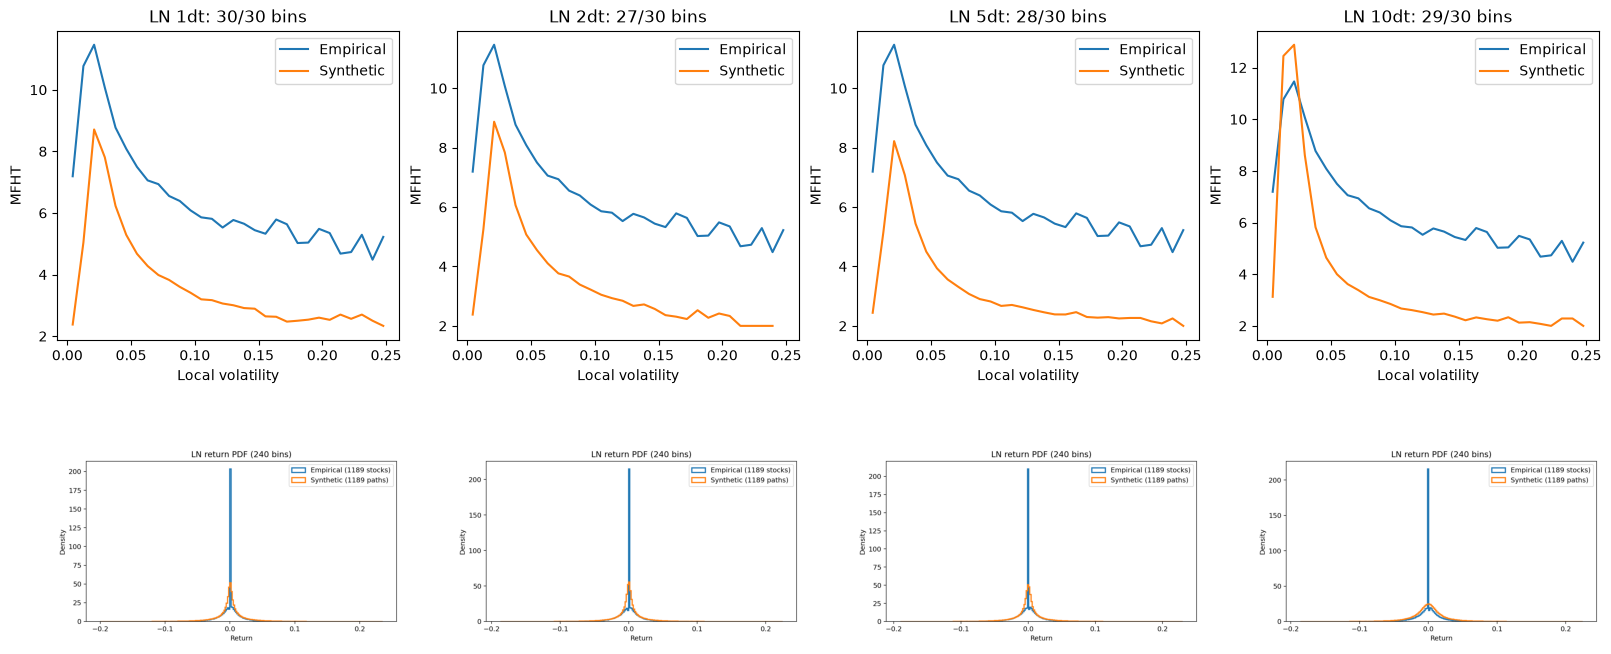

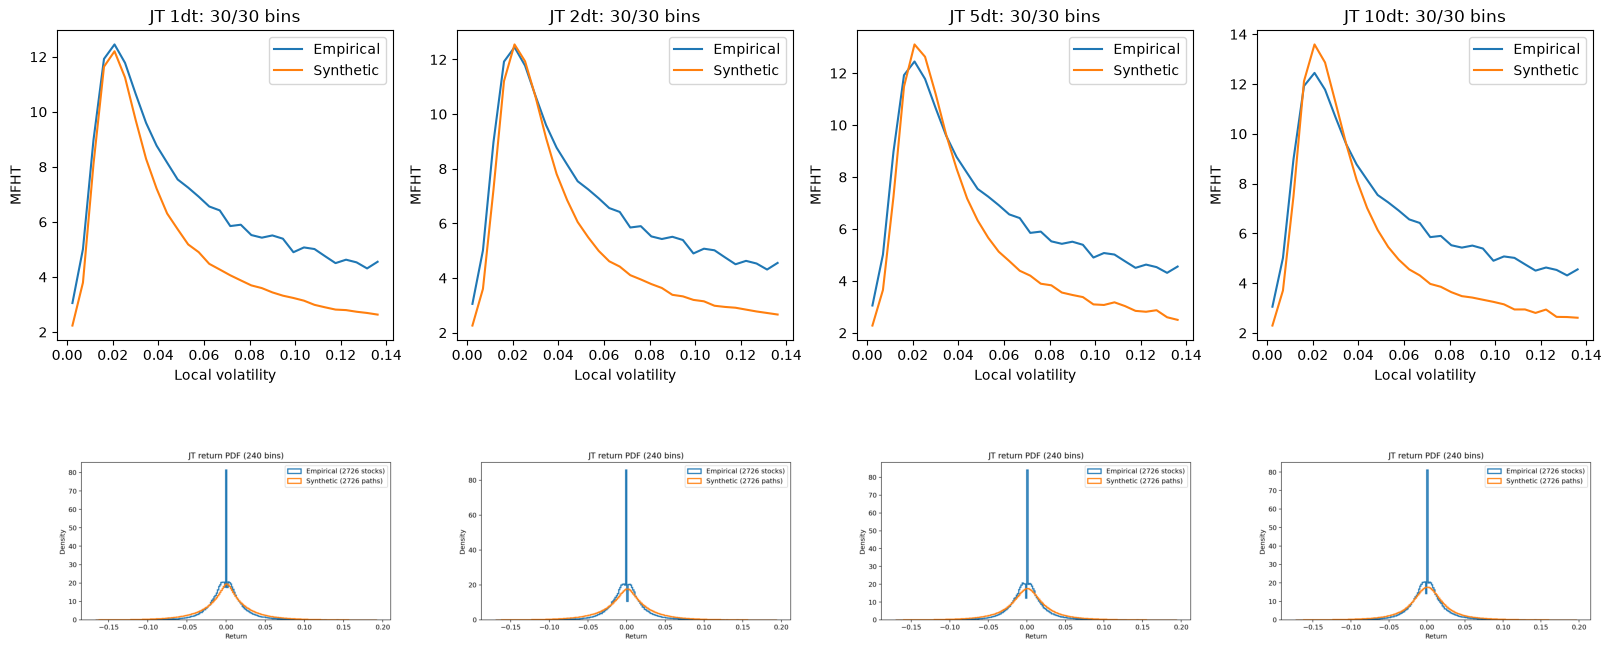

In [13]:
for market in MARKETS:
    if market not in summary:
        continue
    intervals = summary[market].interval_steps.tolist()
    fig, axes = plt.subplots(2, len(intervals), figsize=(4 * len(intervals), 7), layout='constrained')
    axes = np.asarray(axes).reshape(2, len(intervals))
    for column, interval in enumerate(intervals):
        curve_path = FIGURES / market / f'interval_{interval}' / market / f'{market}_m0p1_m1p5_mfht.csv'
        pdf_path = FIGURES / market / f'interval_{interval}' / market / f'{market}_returns_pdf.png'
        if curve_path.is_file():
            curve = pd.read_csv(curve_path)
            fit = curve.fit_bin.astype(bool)
            covered = curve.simulated_bin_covered.astype(bool)
            axes[0, column].plot(curve.loc[fit, 'volatility_midpoint'],
                                 curve.loc[fit, 'empirical_mfht'], label='Empirical')
            axes[0, column].plot(curve.volatility_midpoint, curve.simulated_mfht, label='Synthetic')
            axes[0, column].set(title=f'{market} {interval}dt: {(fit & covered).sum()}/{fit.sum()} bins',
                                xlabel='Local volatility', ylabel='MFHT')
            axes[0, column].legend()
        else:
            axes[0, column].set(title=f'Missing {curve_path.name}')
        if pdf_path.is_file():
            axes[1, column].imshow(plt.imread(pdf_path))
        else:
            axes[1, column].set(title=f'Missing {pdf_path.name}')
        axes[1, column].axis('off')
    plt.show()


## Choose one interval per market

Edit the four values below after reviewing the scores and plots. Running the cell writes `final_selection.json`; copy that file to the workstation's matching sweep folder.


In [14]:
SELECTED_INTERVALS = {'UN': 5, 'UW': 5, 'LN': 10, 'JT': 2}

if any(value is None for value in SELECTED_INTERVALS.values()):
    print('Set all four SELECTED_INTERVALS values to 1, 2, 5, or 10, then rerun this cell.')
else:
    if set(SELECTED_INTERVALS) != set(MARKETS):
        raise ValueError('Selection must contain exactly UN, UW, LN, and JT')
    selected_rows = []
    for market, interval in SELECTED_INTERVALS.items():
        if type(interval) is not int or market not in summary:
            raise ValueError(f'Invalid or unavailable market selection: {market}={interval}')
        matches = summary[market].loc[summary[market].interval_steps == interval]
        if len(matches) != 1 or not np.isfinite(matches.validation_loss.iloc[0]):
            raise ValueError(f'{market} {interval}dt has no finite full validation score')
        parameters = DATA / market / f'interval_{interval}' / 'heston_calibration_parameters.csv'
        if not parameters.is_file():
            raise FileNotFoundError(parameters)
        selected_rows.append({'market': market, 'interval_steps': interval,
                              'validation_loss': matches.validation_loss.iloc[0],
                              'parameters_csv': str(parameters)})
    display(pd.DataFrame(selected_rows))
    selection_path = DATA / 'final_selection.json'
    selection_path.write_text(json.dumps(SELECTED_INTERVALS, indent=2) + '\n', encoding='utf-8')
    print('Saved:', selection_path)


,market,interval_steps,validation_loss,parameters_csv
0,UN,5,0.183558,G:\UNIPA\ECONOFISICA\stabilizing_volatility\da...
1,UW,5,0.581992,G:\UNIPA\ECONOFISICA\stabilizing_volatility\da...
2,LN,10,0.343604,G:\UNIPA\ECONOFISICA\stabilizing_volatility\da...
3,JT,2,0.184912,G:\UNIPA\ECONOFISICA\stabilizing_volatility\da...


Saved: G:\UNIPA\ECONOFISICA\stabilizing_volatility\data\processed\heston_calibration\four_market_sampling_sweep\final_selection.json


## Final independent-ensemble comparison

The workstation script produces independent full-length ensembles for each selected model. The orange line is the per-bin median and shading spans the minimum to maximum across runs when those statistics are available. For MFHT, a bin uses only runs with sufficient events; check `replicates_covered` in its CSV. The return PDF excludes exact-zero returns using the compact `return_pdf_nonzero_band.csv`, so the full return matrices need not be saved. Scores are reported as across-run mean and standard deviation.


,interval_steps,return_pdf_nonzero_total_variation_mean,return_pdf_nonzero_total_variation_std,return_wasserstein_sampled_mean,return_wasserstein_sampled_std,return_loss_mean,return_loss_std,mfht_loss_mean,mfht_loss_std,combined_loss_mean,combined_loss_std,n_events_mean
market,,,,,,,,,,,,
JT,2,0.14967,0.00012,0.00970,0.00006,0.02781,0.00005,0.12995,0.00042,0.18556,0.00042,1884011.94
LN,10,0.05544,0.00022,0.00881,0.00006,0.03111,0.00037,0.28282,0.00746,0.34503,0.00745,559364.46
UN,5,0.06286,0.00020,0.00207,0.00003,0.03749,0.00037,0.10761,0.00094,0.18258,0.00124,485529.51
UW,5,0.13690,0.00031,0.01077,0.00008,0.23660,0.00020,0.10781,0.00085,0.58102,0.00088,477243.64


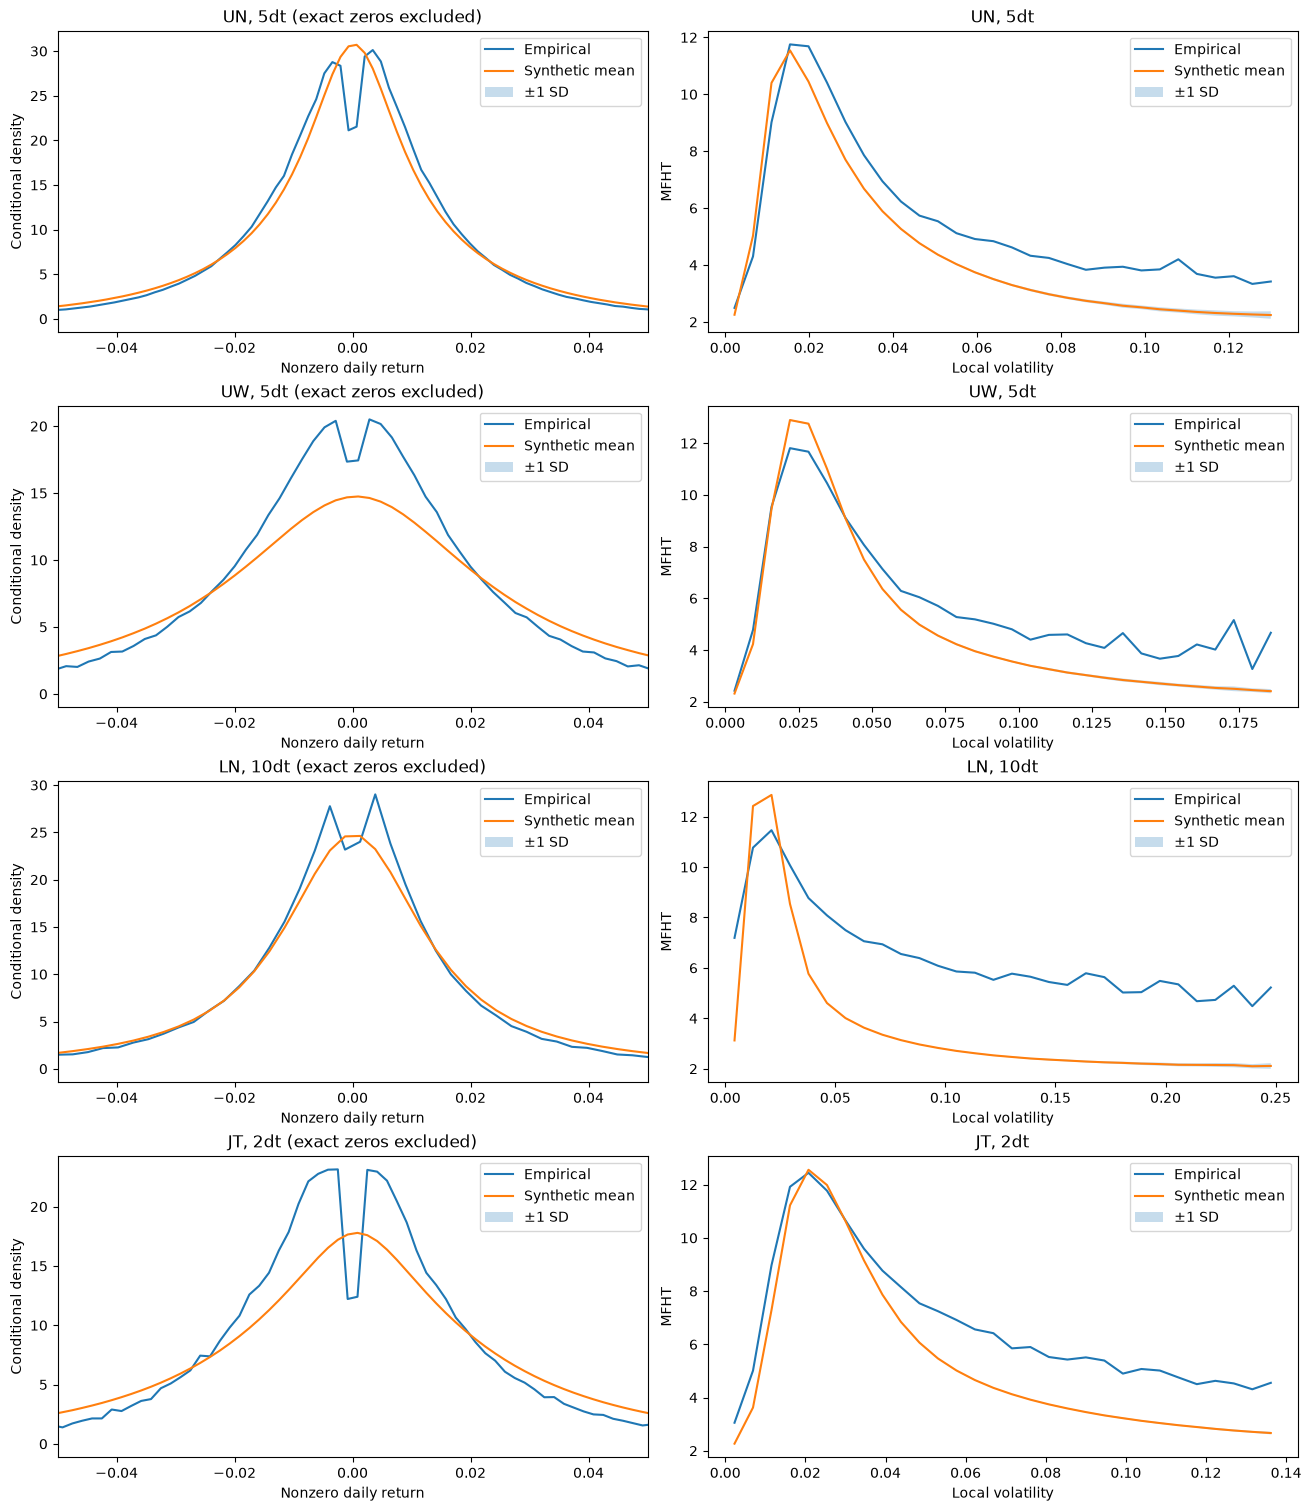

In [15]:
FINAL = DATA / 'replicate_variation_range'
if not FINAL.is_dir():
    FINAL = DATA / 'replicate_variation'
score_path = FINAL / 'replicate_summary.csv'
selection_path = DATA / 'final_selection.json'
if not score_path.is_file() or not selection_path.is_file():
    print('Copy the workstation replicate_variation folder and final_selection.json here first.')
else:
    chosen = json.loads(selection_path.read_text(encoding='utf-8'))
    scores = pd.read_csv(score_path).set_index('market')
    has_nonzero = all((FINAL / market / f'interval_{chosen[market]}' / 'return_pdf_nonzero_band.csv').is_file() for market in MARKETS)
    if not has_nonzero:
        print('Zero-excluded bands are unavailable in these outputs. Rerun scripts/heston_sampling_replicates.py to produce them; showing the older zero-inclusive PDFs for now.')
    pdf_name = 'return_pdf_nonzero_band.csv' if has_nonzero else 'return_pdf_band.csv'
    tv_name = 'return_pdf_nonzero_total_variation' if has_nonzero else 'return_pdf_total_variation'
    display(scores[['interval_steps', f'{tv_name}_mean',
                    f'{tv_name}_std', 'return_wasserstein_sampled_mean',
                    'return_wasserstein_sampled_std', 'return_loss_mean', 'return_loss_std',
                    'mfht_loss_mean', 'mfht_loss_std', 'combined_loss_mean',
                    'combined_loss_std', 'n_events_mean']].round(5))
    fig, axes = plt.subplots(4, 2, figsize=(13, 15), layout='constrained')
    for row, market in enumerate(MARKETS):
        interval = chosen[market]
        folder = FINAL / market / f'interval_{interval}'
        for column, (name, x, empirical, xlabel, ylabel) in enumerate([
            (pdf_name, 'return_midpoint', 'empirical_density', 'Nonzero daily return' if has_nonzero else 'Daily return', 'Conditional density' if has_nonzero else 'Density'),
            ('mfht_band.csv', 'volatility_midpoint', 'empirical_mfht', 'Local volatility', 'MFHT')]):
            frame = pd.read_csv(folder / name)
            ax = axes[row, column]
            xx = frame[x].to_numpy(dtype=float)
            ax.plot(xx, frame[empirical], label='Empirical')
            if {'synthetic_median', 'synthetic_min', 'synthetic_max'}.issubset(frame.columns):
                ax.plot(xx, frame.synthetic_median, label='Synthetic median')
                ax.fill_between(xx, frame.synthetic_min.to_numpy(dtype=float), frame.synthetic_max.to_numpy(dtype=float), alpha=0.25, label='Synthetic min–max')
            else:
                yy = frame.synthetic_mean.to_numpy(dtype=float)
                sd = frame.synthetic_std.to_numpy(dtype=float)
                ax.plot(xx, yy, label='Synthetic mean')
                ax.fill_between(xx, yy - sd, yy + sd, alpha=0.25, label='±1 SD (older output)')
            ax.set(title=f'{market}, {interval}dt' + (' (exact zeros excluded)' if column == 0 and has_nonzero else ''), xlabel=xlabel, ylabel=ylabel)
            if column == 0:
                ax.set_xlim(-0.05, 0.05)
            ax.legend()
    plt.show()


## Optional return-PDF rebinning

The final comparison above already excludes exact zeros without loading return matrices. To experiment with a different bin count, set `REBIN_MARKET` and `REBIN_INTERVAL` below. This optional cell needs saved final series or an exported plot series.


In [19]:
REBIN_MARKET = 'UN'  # e.g. 'UN'
REBIN_INTERVAL = 5
BINS = 240  # use an even number so zero is a bin boundary
if REBIN_MARKET is not None:
    if BINS < 2 or BINS % 2:
        raise ValueError('BINS must be an even number of at least 2')
    final_dir = FINAL / REBIN_MARKET / f'interval_{REBIN_INTERVAL}'
    paths = sorted(final_dir.glob(f'{REBIN_MARKET}_returns_replicate_*.pkl'))
    if not paths:
        plot_path = DATA / REBIN_MARKET / f'interval_{REBIN_INTERVAL}' / f'{REBIN_MARKET}_synthetic_returns_plot.pkl'
        if plot_path.is_file():
            paths = [plot_path]
    if not paths:
        print(f'No saved synthetic series for {REBIN_MARKET} at {REBIN_INTERVAL}dt. Export the plot series with scripts/export_heston_sampling_series.py --sweep-dir {DATA / REBIN_MARKET} --market {REBIN_MARKET} --intervals {REBIN_INTERVAL}, then copy its pickle here.')
    else:
        empirical = pd.read_pickle(ROOT / 'data/interim' / f'{REBIN_MARKET}.pickle').loc['1980-01-01':'2022-07-01']
        empirical = empirical.loc[:, empirical.notna().sum() >= 3030]
        real = empirical.to_numpy(dtype=float, copy=False).ravel()
        real = real[np.isfinite(real)]
        real_zero_fraction = np.mean(real == 0)
        real = real[real != 0]
        span = max(abs(np.quantile(real, 0.001)), abs(np.quantile(real, 0.999)))
        edges = np.linspace(-span, span, BINS + 1)
        edges[BINS // 2] = 0.0
        widths = np.diff(edges)
        real_counts = np.histogram(real, bins=edges)[0]
        real_density = real_counts / (real_counts.sum() * widths)
        synthetic_densities = []
        synthetic_zero_fractions = []
        for path in paths:
            values = pd.read_pickle(path).to_numpy(dtype=float, copy=False).ravel()
            values = values[np.isfinite(values)]
            synthetic_zero_fractions.append(np.mean(values == 0))
            values = values[values != 0]
            counts = np.histogram(values, bins=edges)[0]
            synthetic_densities.append(counts / (counts.sum() * widths))
        densities = np.asarray(synthetic_densities)
        mean_density = densities.mean(axis=0)
        fig, ax = plt.subplots(figsize=(8, 4.5))
        ax.stairs(real_density, edges, label='Empirical, nonzero')
        ax.stairs(mean_density, edges, label=f'Synthetic, nonzero ({len(paths)} run(s))')
        if len(paths) > 1:
            sd_density = densities.std(axis=0, ddof=1)
            midpoints = (edges[:-1] + edges[1:]) / 2
            ax.fill_between(midpoints, mean_density - sd_density, mean_density + sd_density, alpha=0.2, label='Synthetic ±1 SD')
        ax.set(title=f'{REBIN_MARKET} {REBIN_INTERVAL}dt: {BINS} bins, exact zeros excluded', xlabel='Daily return', ylabel='Conditional density', xlim=(-0.05, 0.05))
        ax.legend()
        plt.show()
        print(f'Exact-zero fraction before exclusion: empirical {real_zero_fraction:.3%}; synthetic mean {np.mean(synthetic_zero_fractions):.3%}')


No saved synthetic series for UN at 5dt. Export the plot series with scripts/export_heston_sampling_series.py --sweep-dir G:\UNIPA\ECONOFISICA\stabilizing_volatility\data\processed\heston_calibration\four_market_sampling_sweep\UN --market UN --intervals 5, then copy its pickle here.
